In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [7]:
from datetime import datetime, timedelta

import polars as pl

from tests.helpers.collector import PolarsCollector
from tests.helpers.simulation_runner import SimulationTestRunner
from tests.helpers.simulator_model import SimulatorModel
from thrs.control.modules.dc import DC_MODULE_DESCRIPTION, DcControl, DcParameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    Converter,
)
from thrs.input_output.modules.dc import (
    DcControlValues,
    DcSensorValues,
    DcSimulationInputs,
    DcSimulationOutputs,
)
from thrs.simulation.models.fmu_paths import dc_path

start_time = datetime.fromtimestamp(0)
minutes = 60
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)

SEAWATER_TEMPERATURE = 20.0

simulation_inputs = DcSimulationInputs(
    dc_brightloop_fwd1=Converter(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    dc_brightloop_fwd2=Converter(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    dc_ugrid1=Converter(heat_flow=Stamped.stamp(2000), active=Stamped.stamp(True)),
    dc_ugrid2=Converter(heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)),
    dc_brightloop_aft1=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    dc_brightloop_aft2=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    dc_brightloop_aft3=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    dc_brightloop_aft4=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    dc_seawater_supply=Boundary(
        temperature=Stamped.stamp(SEAWATER_TEMPERATURE), flow=Stamped.stamp(64)
    ),
    dc_dhw_supply=Boundary(temperature=Stamped.stamp(35), flow=Stamped.stamp(20)),
)

parameters = DcParameters(
    maximum_supply_temperature=63,
    recovery_temperature=65,
    brightloop_return_temperature=65,
    ugrid_return_temperature=65,
)


dc_model = SimulatorModel(
    fmu_path=dc_path,
    sensor_values_cls=DcSensorValues,
    control_values_cls=DcControlValues,
    simulation_outputs_cls=DcSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=DcControl,
    alarms=BaseAlarms(),
    start_time=start_time,
)
with dc_model.simulation() as simulation:
    runner = SimulationTestRunner.from_module(
        DC_MODULE_DESCRIPTION, parameters, simulation
    )
    collector = PolarsCollector()
    runner.run(int(duration.total_seconds()), collector)
    result = collector.result()

[WARNING] State logging: Please enable result storing to get state names


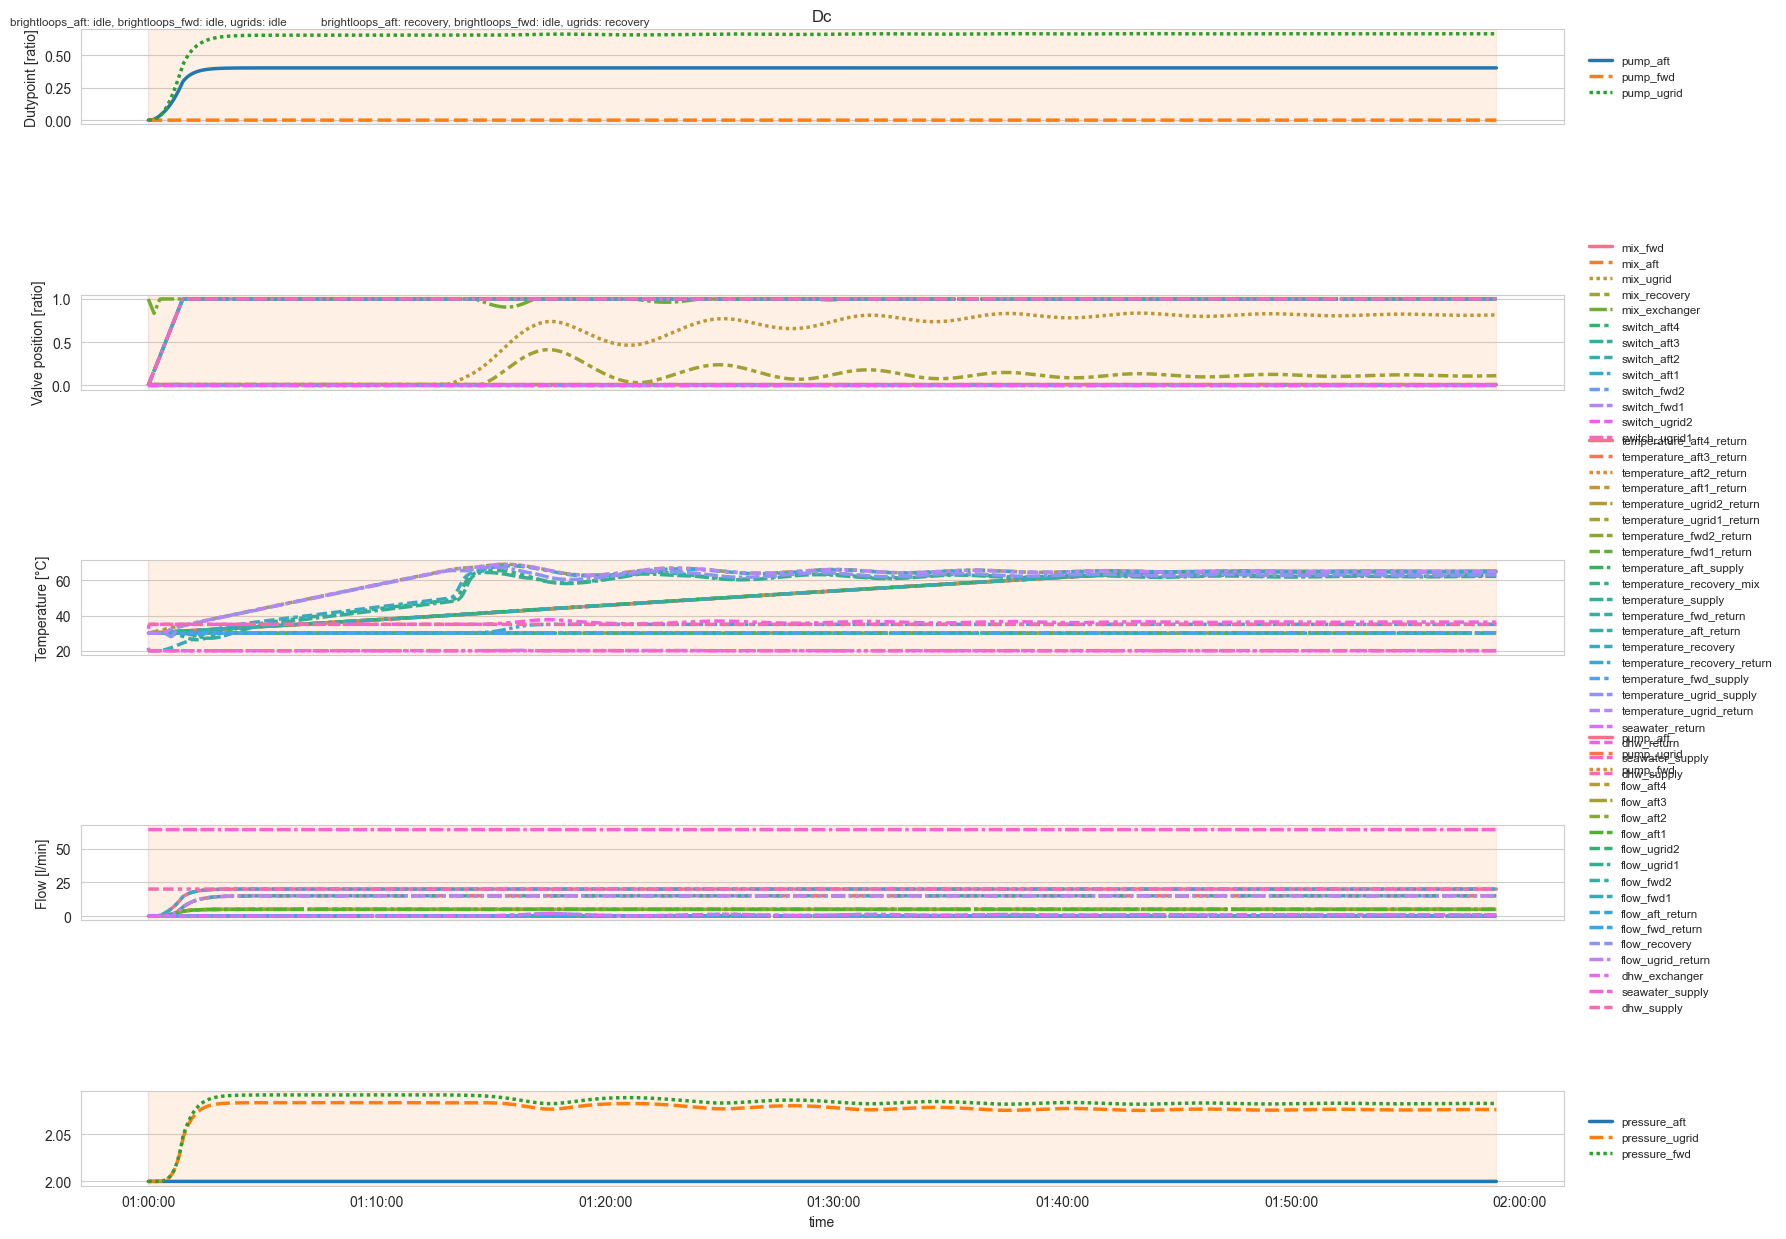

In [8]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/dc.png");

In [5]:
from thrs.simulation.io_mapping import build_fmu_key_mapping

result.select(
    [
        "time",
        *build_fmu_key_mapping(DcControlValues, fmu_only=False).values(),
        *build_fmu_key_mapping(DcSimulationInputs, fmu_only=False).values(),
    ]
).write_csv("csv/dc_run_inputs_only_aft.csv")


result.select(
    [
        "time",
        *build_fmu_key_mapping(DcSensorValues, fmu_only=False).values(),
        *build_fmu_key_mapping(DcSimulationOutputs, fmu_only=False).values(),
    ]
).write_csv("csv/dc_run_outputs_only_aft.csv")